Import the libraries and make a dataframe

In [8]:
import numpy as np
import pandas as pd

np.random.seed(23)

# Class 1
mu_vec1 = np.array([0,0,0])
cov_mat1 = np.eye(3)

class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample, columns=['feature1','feature2','feature3'])
df['target'] = 1

# Class 2
mu_vec2 = np.array([1,1,1])
cov_mat2 = np.eye(3)

class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample, columns=['feature1','feature2','feature3'])
df1['target'] = 0

# Combine
df = pd.concat([df, df1], ignore_index=True)

# Shuffle properly
df = df.sample(frac=1).reset_index(drop=True)

df.head()

,feature1,feature2,feature3,target
0,-0.367548,-1.137460,-1.322148,1
1,0.177061,-0.598109,1.226512,0
2,0.420623,0.411620,-0.071324,1
3,1.968435,-0.547788,-0.679418,1
4,-2.506230,0.146960,0.606195,1


3-D plot the data.

In [9]:
import plotly.express as px

# Convert once
df['target'] = df['target'].astype(str)

fig = px.scatter_3d(
    df,
    x='feature1',
    y='feature2',
    z='feature3',
    color='target',
    color_discrete_map={'0': 'red', '1': 'blue'}
)

fig.update_traces(
    marker=dict(size=8, line=dict(width=1, color='black'))
)

fig.update_layout(
    title="3D Feature Space Visualization",
    scene=dict(
        xaxis_title='Feature 1',
        yaxis_title='Feature 2',
        zaxis_title='Feature 3'
    )
)

fig.show()


In [10]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['feature1','feature2','feature3']] = scaler.fit_transform(
    df[['feature1','feature2','feature3']]
)

In [11]:
# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov(df[['feature1','feature2','feature3']].values, rowvar=False)
print("Covariance Matrix:\n", covariance_matrix)


Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [12]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

print("Eigen Values:\n", eigen_values)
print("\nEigen Vectors:\n", eigen_vectors)

Eigen Values:
 [1.3536065  0.94557084 0.77774573]

Eigen Vectors:
 [[-0.53875915 -0.69363291  0.47813384]
 [-0.65608325 -0.01057596 -0.75461442]
 [-0.52848211  0.72025103  0.44938304]]


3-D projection of PCA.

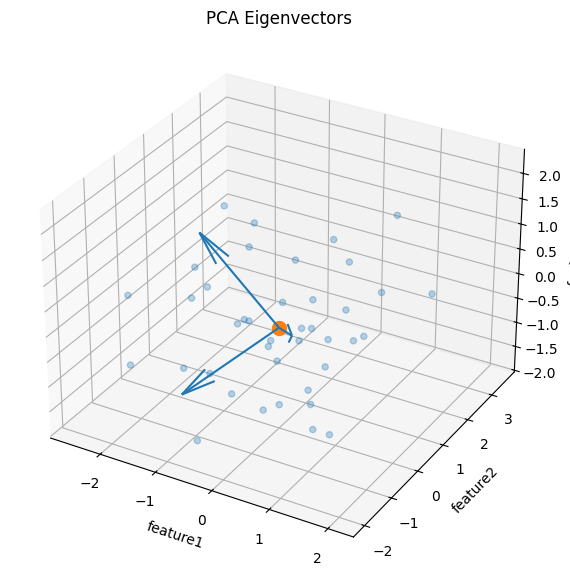

In [13]:
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, renderer.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)

import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

# Data points
ax.scatter(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    alpha=0.3
)

# Mean (≈ 0 after StandardScaler)
mean = df[['feature1','feature2','feature3']].mean().values
ax.scatter(mean[0], mean[1], mean[2], s=100)

# Eigenvectors as arrows (robust)
# Ensure sorted eigenvectors (PC1 first)
idx = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[idx]
eigen_vectors = eigen_vectors[:, idx]

scale = 2.0  # for visibility

for i in range(3):
    v = eigen_vectors[:, i]
    ax.quiver(
        mean[0], mean[1], mean[2],   # origin
        v[0], v[1], v[2],            # direction
        length=scale,
        normalize=True
    )

ax.set_xlabel('feature1')
ax.set_ylabel('feature2')
ax.set_zlabel('feature3')

plt.title('PCA Eigenvectors')
plt.show()

Eigen vectors.

In [14]:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

Coverting the 3D data into 2D.

In [15]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


2D scatterplot of the PCA transformed data.

In [ ]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,line=dict(width=2,color='DarkSlateGrey')),selector=dict(mode='markers'))
fig.show()